# 2.3 — Feature Engineering & Model Comparison

Pipeline organization, factor analysis tuning, and systematic model comparison across binary, AHI-threshold sweep, multiclass, and ordinal classification approaches.

## Setup

In [1]:
from __future__ import annotations

import json
import os
import re
import warnings
from pathlib import Path
from types import SimpleNamespace

import lightgbm as lgb
import matplotlib.pyplot as plt
import mlflow
import mlflow.data
import mlflow.sklearn
import mlflow.xgboost
import mord
import numpy as np
import pandas as pd
import xgboost as xgb
from xgboost import XGBClassifier

from IPython.display import display
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.over_sampling import SMOTE
from mlflow.models.signature import infer_signature
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from src.eval import (
    evaluate_binary as evaluate,
    evaluate_multiclass as evaluate_mc,
    run_fa_shap_eval,
    safe_mlflow_key as _safe_metric_key,
    tag_comparison_df as _tag,
)
from src.features import feature_encoder, raw_data_loader
from src.features.transformers import Factor_Analyzer_Transformer
from src.modeling.fa_tuning import (
    build_best_factor_analysis_pipeline,
    tune_factor_analysis_rotation,
)
from src.plots import parallel_analysis
from src.utils.data_utils import convert_ahi, make_multiclass_y

warnings.filterwarnings("ignore")


In [2]:
os.environ["MLFLOW_EXPERIMENT_NAME"] = "2.3-jp-feature-engineering"

mlflow.set_tracking_uri("file:///Users/jack/Repos/apnea-predictor/mlruns")
mlflow.set_experiment(os.getenv("MLFLOW_EXPERIMENT_NAME", "default_experiment"))

<Experiment: artifact_location='file:///Users/jack/Repos/apnea-predictor/mlruns/825373606965551241', creation_time=1776728062398, experiment_id='825373606965551241', last_update_time=1776728062398, lifecycle_stage='active', name='2.3-jp-feature-engineering', tags={}, workspace='default'>

## Data Loading & Encoding

In [3]:
df = raw_data_loader.load_and_clean_raw("..")

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1880 entries, 0 to 1880
Columns: 409 entries, ('participants_age', 'modified_dem_0110', 'demographics') to ('apnea_hypopnea_index', 'ahi', 'output')
dtypes: Int64(8), boolean(1), datetime64[ns](19), float64(379), object(2)
memory usage: 5.9+ MB


In [4]:
df = feature_encoder.encode_features(df)

df = df.drop(columns=['ess_total_score', 'isi_total_score'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1687 entries, 0 to 1686
Columns: 147 entries, age to dream_recall_frequency_rarely_or_never
dtypes: float64(136), int64(11)
memory usage: 1.9 MB


In [5]:
# ── canonical X / y (binary AHI≥5) and shared train/test split ───────────────
X = df.drop(columns=["ahi"])
y = convert_ahi(df["ahi"])

_splits = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = _splits[0], _splits[1], _splits[2], _splits[3]

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos

print(f"Binary (AHI≥5) — train: {neg} negative, {pos} positive  (spw={spw:.2f})")
print(f"Binary (AHI≥5) — test:  {(y_test==0).sum()} negative, {(y_test==1).sum()} positive")


Binary (AHI≥5) — train: 459 negative, 890 positive  (spw=0.52)
Binary (AHI≥5) — test:  115 negative, 223 positive


In [6]:
rotations = [
    "varimax",  # (orthogonal rotation)
    "promax",  # (oblique rotation)
    "oblimin",  # (oblique rotation)
    "oblimax",  # (orthogonal rotation)
    "quartimin",  # (oblique rotation)
    "quartimax",  # (orthogonal rotation)
    "equamax"  # (orthogonal rotation)
]


## Parallel Analysis

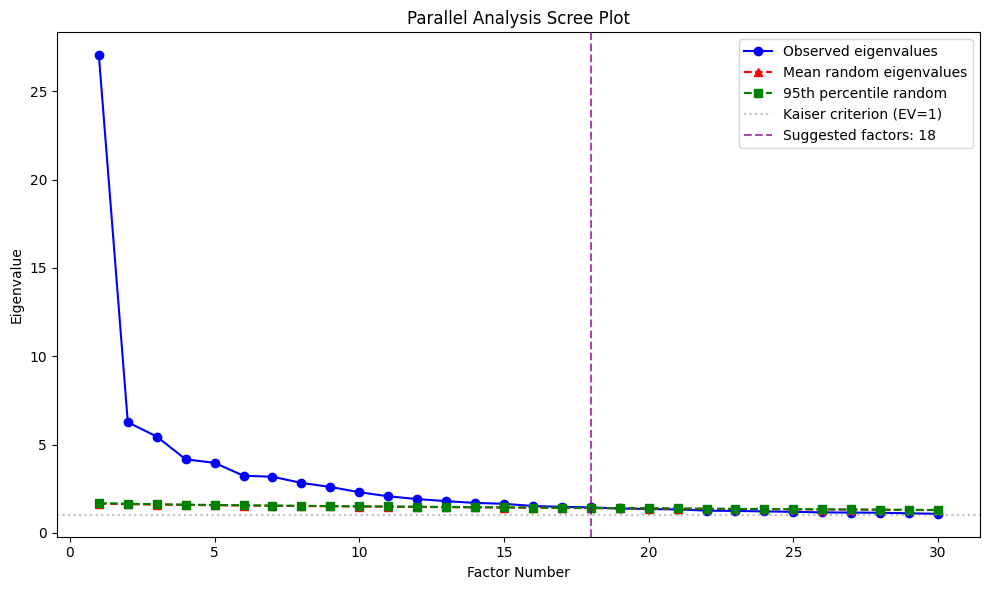


Parallel analysis suggests 18 factors


In [7]:
parallel_analysis(df.drop(columns=["ahi"]), n_iterations=1000)  # parallel analysis suggests 18 factors

## Hyperparameter Tuning: FA + XGBoost Pipeline

In [8]:
BEST_PARAMS_PATH = "../data/interim/best_fa_xgb_params.json"

# ── selectable optimisation metric ───────────────────────────────────────────
# Options: "roc_auc" | "f1_macro" | "f1" | "average_precision" | "accuracy"
TUNING_SCORING = "average_precision"

# Set True to ignore any cached params and re-run tuning from scratch
FORCE_RETUNE = False

xgb_search_space = {
    "n_estimators": {"type": "int", "low": 100, "high": 500, "step": 50},
    "max_depth": {"type": "int", "low": 3, "high": 8},
    "min_child_weight": {"type": "int", "low": 1, "high": 10},
    "learning_rate": {"type": "float", "low": 0.01, "high": 0.3, "log": True},
    "subsample": {"type": "float", "low": 0.6, "high": 1.0, "step": 0.1},
    "colsample_bytree": {"type": "float", "low": 0.6, "high": 1.0, "step": 0.1},
    "gamma": {"type": "float", "low": 0.0, "high": 5.0, "step": 0.5},
}

search_dataset = mlflow.data.from_pandas(
    pd.concat([X, y.rename("ahi")], axis=1),
    name="2.3-sleep-apnea-fa-xgb-search",
    targets="ahi",
)

if FORCE_RETUNE or not Path(BEST_PARAMS_PATH).exists():
    with mlflow.start_run(run_name="joint_fa_xgb_optuna_search"):

        mlflow.log_input(search_dataset, context="train")

        mlflow.set_tag("model_type", "factor-analysis-xgboost-pipeline")

        mlflow.set_tag("search_type", "joint_fa_xgb_optuna")

        mlflow.log_param("scoring", TUNING_SCORING)

        mlflow.log_param("n_splits", 5)

        mlflow.log_param("n_trials", 40)

        mlflow.log_param("fixed_n_factors", 18)

        mlflow.log_param("candidate_rotations", ",".join(rotations))

        mlflow.log_dict(xgb_search_space, "xgb_search_space.json")

        tuning_result = tune_factor_analysis_rotation(
            X,
            y,
            rotations=rotations,
            n_factors=18,
            n_splits=5,
            n_trials=40,
            scoring=TUNING_SCORING,
            xgb_search_space=xgb_search_space,
            random_state=42,
        )

        best_fa_pipeline = build_best_factor_analysis_pipeline(tuning_result)

        best_fa_pipeline.fit(X, y)

        best_xgb_params = {
            key: value
            for key, value in tuning_result.best_params.items()
            if key not in {"rotation", "n_factors"}
        }

        mlflow.log_param("best_rotation", tuning_result.best_rotation)

        mlflow.log_param("best_n_factors", tuning_result.best_params.get("n_factors", 18))

        mlflow.log_params({f"best_{key}": value for key, value in best_xgb_params.items()})

        mlflow.log_metric(f"best_mean_cv_{TUNING_SCORING}", float(tuning_result.best_score))

        mlflow.log_metric("completed_trials", float(len(tuning_result.trial_results)))

        mlflow.log_text(
            tuning_result.rotation_summary.to_csv(index=False) or "",
            "rotation_summary.csv",
        )

        mlflow.log_text(
            tuning_result.trial_results.to_csv(index=False) or "",
            "trial_results.csv",
        )

        signature = infer_signature(X, best_fa_pipeline.predict(X))

        mlflow.sklearn.log_model(
            best_fa_pipeline,
            name="best_fa_xgb_pipeline",
            signature=signature,
        )

        with open(BEST_PARAMS_PATH, "w") as f:
            json.dump(tuning_result.best_params, f, indent=2)

    print(f"Best rotation: {tuning_result.best_rotation}")
    print(f"Best n_factors: {tuning_result.best_params.get('n_factors', 18)}")
    print(f"Best mean CV {TUNING_SCORING}: {tuning_result.best_score:.4f}")
    print("Best XGBoost params:")
    print(best_xgb_params)
    display(tuning_result.rotation_summary)
    display(tuning_result.trial_results)

# Always load from disk so downstream cells work regardless of whether tuning ran
with open(BEST_PARAMS_PATH) as f:
    _saved_params = json.load(f)

best_fa_pipeline = build_best_factor_analysis_pipeline(
    SimpleNamespace(
        best_params=_saved_params,
        best_rotation=_saved_params.get("rotation"),
        best_method=_saved_params.get("method"),   # None falls back to "minres" in fa_tuning.py
    )
)
best_xgb_params = {k: v for k, v in _saved_params.items() if k not in {"rotation", "n_factors"}}

print(f"Loaded best_rotation : {_saved_params.get('rotation')}")
print(f"Loaded best_n_factors: {_saved_params.get('n_factors', 18)}")
print(f"Loaded XGBoost params : {best_xgb_params}")

# ── metric used for selecting & ranking models in comparison cells ─────────────
# Maps TUNING_SCORING values to column names returned by evaluate_binary /
# evaluate_multiclass. "average_precision" has no direct column so falls back
# to "roc_auc" (the closest available discriminative metric).
_SCORING_TO_COL = {
    "roc_auc": "roc_auc",
    "average_precision": "roc_auc",
    "f1_macro": "f1_macro",
    "f1": "f1_macro",
    "accuracy": "accuracy",
}
SORT_METRIC    = _SCORING_TO_COL.get(TUNING_SCORING, "average_precision")
SORT_METRIC_MC = "roc_auc_ovr" if SORT_METRIC == "roc_auc" else SORT_METRIC


Loaded best_rotation : quartimax
Loaded best_n_factors: 18
Loaded XGBoost params : {'method': 'minres', 'n_estimators': 350, 'max_depth': 3, 'min_child_weight': 5, 'learning_rate': 0.033331461562247956, 'subsample': 0.7, 'colsample_bytree': 0.9, 'gamma': 4.0}


Joint FA+XGBoost Optuna search across 7 rotations and 40 trials. All rotation differences were marginal. Best result saved to disk so subsequent runs skip the search.

**Best tuned result (ROC-AUC)** (varimax, 18 factors, ROC-AUC ≈ 0.53):\
`n_estimators=450, max_depth=6, min_child_weight=9, learning_rate=0.016, subsample=0.6, colsample_bytree=1.0, gamma=5.0`

## Initial Evaluation: Tuned vs Non-Tuned Pipeline

In [9]:
from src.eval import run_fa_shap_eval

run_fa_shap_eval(
    best_fa_pipeline, X_train, X_test, y_train, y_test,
    run_name="tuned_fa_xgb_shap_eval",
    extra_params={
        "pipeline": "tuned_fa_xgb",
        "rotation": best_xgb_params.get("rotation", "varimax"),
        "n_factors": 18,
        **{f"xgb_{k}": v for k, v in best_xgb_params.items()},
    },
)

ROC-AUC: 0.5323
Accuracy: 0.6598
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       115
           1       0.66      1.00      0.80       223

    accuracy                           0.66       338
   macro avg       0.33      0.50      0.40       338
weighted avg       0.44      0.66      0.52       338

[[  0 115]
 [  0 223]]


{'roc_auc': np.float64(0.5322869955156951),
 'accuracy': 0.6597633136094675,
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.00      0.00      0.00       115\n           1       0.66      1.00      0.80       223\n\n    accuracy                           0.66       338\n   macro avg       0.33      0.50      0.40       338\nweighted avg       0.44      0.66      0.52       338\n',
 'confusion_matrix': array([[  0, 115],
        [  0, 223]])}

The tuned hyperparameters (`gamma=5.0`, very high regularization) cause the model to collapse to predicting only the majority class. The non-tuned default pipeline below avoids this.

In [10]:
factor_analyzer = best_fa_pipeline.steps[0][1]

factor_analyzer.get_top_loadings()

Top loadings for Factor_1:
fati_interferes_with_work_fam_social_fss     0.895377
fati_causes_freq_probs_for_me_fss            0.894164
fati_interferes_with_responsibilities_fss    0.854119
fati_top_three_disabling_sympts_fss          0.850892
fati_interferes_with_phys_function_fss       0.843528
fati_prevents_sustained_phys_func_fss        0.823488
i_am_easily_fati_fss                         0.801699
difficulty_concentrating_fosq                0.771533
Name: Factor_1, dtype: float64


Top loadings for Factor_2:
diff_staying_asleep_isi                      0.698083
diff_falling_asleep_isi                      0.694196
diff_falling_asleep_isq                      0.675416
troub_slp_nose                               0.671298
slp_quality_sw                               0.505511
problems_waking_up_too_early_isi             0.496848
latency_sw                                   0.494417
how_satisfied_with_curr_sleep_pattern_isi    0.492654
Name: Factor_2, dtype: float64


Top loadings for

In [11]:
non_tuned_pipeline = build_best_factor_analysis_pipeline(
    SimpleNamespace(
        best_params={
            "rotation": "varimax",
            "n_factors": 18,
        },
        best_rotation="varimax",
        best_method=None,
    )
)

In [12]:
run_fa_shap_eval(
    non_tuned_pipeline, X_train, X_test, y_train, y_test,
    run_name="non_tuned_fa_xgb_shap_eval",
    extra_params={"pipeline": "non_tuned_fa_xgb", "rotation": "varimax", "n_factors": 18},
)

ROC-AUC: 0.5221
Accuracy: 0.6450
              precision    recall  f1-score   support

           0       0.43      0.14      0.21       115
           1       0.67      0.91      0.77       223

    accuracy                           0.64       338
   macro avg       0.55      0.52      0.49       338
weighted avg       0.59      0.64      0.58       338

[[ 16  99]
 [ 21 202]]


{'roc_auc': np.float64(0.5220900760382141),
 'accuracy': 0.6449704142011834,
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.43      0.14      0.21       115\n           1       0.67      0.91      0.77       223\n\n    accuracy                           0.64       338\n   macro avg       0.55      0.52      0.49       338\nweighted avg       0.59      0.64      0.58       338\n',
 'confusion_matrix': array([[ 16,  99],
        [ 21, 202]])}

Non-tuned pipeline predicts both classes and achieves reasonable recall. Most important SHAP factors:

- **FA_1** — fatigue / physical functioning (FSS)
- **FA_3** — excessive daytime sleepiness (ESS, MAP)
- **FA_2** — anxiety / depression (GAD, PHQ)
- **FA_10** — sleep fragmentation (ISQ)
- **FA_5** — sleep impact on daily life (ISQ)
- **FA_8** — family psychiatric history (MDHX)

In [13]:
non_tuned_pipeline[0].get_top_loadings()

Top loadings for Factor_1:
fati_interferes_with_phys_function_fss       0.832786
fati_prevents_sustained_phys_func_fss        0.824393
fati_top_three_disabling_sympts_fss          0.819425
fati_causes_freq_probs_for_me_fss            0.815738
fati_interferes_with_responsibilities_fss    0.812848
fati_interferes_with_work_fam_social_fss     0.798713
i_am_easily_fati_fss                         0.783652
lower_motivation_when_fati_fss               0.586320
Name: Factor_1, dtype: float64


Top loadings for Factor_2:
not_able_to_control_worrying_freq_gad     0.818536
worry_too_much_diff_things_freq_gad       0.781222
feeling_anxious_freq_gad                  0.728557
feel_bad_abt_yourself_freq_phq            0.699199
feel_as_if_awful_might_happen_freq_gad    0.687949
feel_depressed_freq_phq                   0.680994
trouble_relaxing_freq_gad                 0.638659
easily_annoyed_freq_gad                   0.565541
Name: Factor_2, dtype: float64


Top loadings for Factor_3:
ess_chance_of

Top loadings for Factor_1:\
\
fati_interferes_with_phys_function_fss       0.832786\
fati_prevents_sustained_phys_func_fss        0.824393\
fati_top_three_disabling_sympts_fss          0.819425\
fati_causes_freq_probs_for_me_fss            0.815738\
fati_interferes_with_responsibilities_fss    0.812848\
fati_interferes_with_work_fam_social_fss     0.798713\
i_am_easily_fati_fss                         0.783652\
lower_motivation_when_fati_fss               0.586320\
Name: Factor_1, dtype: float64\
\
\
Top loadings for Factor_3:\
\
ess_chance_of_dozing_inactive_public                                      0.696736\
ess_chance_of_dozing_in_a_car_while_stopped_for_few_minutes_in_traffic    0.687985\
map_index_3_excessive_daytime_sleepiness_                                 0.657424\
ess_chance_of_dozing_sitting_quietly_after_lunch_without_alcohol          0.656338\
ess_chance_of_dozing_sitting_and_talking_to_someone                       0.613317\
difficulty_operating_motor_vehicles_for_short_distances_fosq              0.609417\
ess_chance_of_dozing_car_passenger_hr                                     0.598727\
fall_asleep_driving_map                                                   0.598459\
Name: Factor_3, dtype: float64\
\
\
Top loadings for Factor_2:\
not_able_to_control_worrying_freq_gad     0.818536\
worry_too_much_diff_things_freq_gad       0.781222\
feeling_anxious_freq_gad                  0.728557\
feel_bad_abt_yourself_freq_phq            0.699199\
feel_as_if_awful_might_happen_freq_gad    0.687949\
feel_depressed_freq_phq                   0.680994\
trouble_relaxing_freq_gad                 0.638659\
easily_annoyed_freq_gad                   0.565541\
Name: Factor_2, dtype: float64\
\
\
Top loadings for Factor_10:\
difficulty_staying_asleep_isq                                    0.761898\
multiple_awakenings_isq                                          0.759901\
feel_sleep_not_sound_isq                                         0.738108\
feel_sleep_unrefreshing_isq                                      0.663080\
sleep_made_you_fatigued_isq                                      0.352356\
frequent_wakenings_map                                           0.224237\
how_noticeable_is_sleep_problem_impacting_quality_of_life_isi    0.219436\
diff_staying_asleep_isi                                          0.209770\
Name: Factor_10, dtype: float64\
\
\
Top loadings for Factor_5:\
sleep_affected_other_important_parts_of_life_isq    0.662083\
sleep_affected_your_social_life_isq                 0.661912\
sleep_caused_trouble_concentrating_isq              0.642619\
sleep_affected_work_isq                             0.627544\
sleep_made_you_irritable_isq                        0.595189\
sleep_made_you_fatigued_isq                         0.577808\
how_sleepy_do_you_feel_during_the_day_isq           0.525536\
feel_sleep_unrefreshing_isq                         0.376469\
Name: Factor_5, dtype: float64\
\
\
Top loadings for Factor_8:\
family_history_of_depression_mdhx                         0.658898\
family_history_of_psychiatric_treatment_mdhx              0.655571\
family_history_of_anxiety_mdhx                            0.606763\
family_history_of_other_psychiatric_illness_mdhx          0.473401\
psychiatric_or_mental_health_problem_mdhx                 0.359879\
family_history_of_fibromyalgia_or_chronic_fatigue_mdhx    0.354823\
family_history_of_insomnia_mdhx                           0.335192\
family_history_of_restless_leg_syndrome_mdhx              0.298959\
Name: Factor_8, dtype: float64\

In [14]:
# create dummy model
from sklearn.dummy import DummyClassifier

dummy_classifier = DummyClassifier(strategy="most_frequent")

with mlflow.start_run(run_name="dummy_classifier_eval"):

    dummy_preds = dummy_classifier.fit(X_train, y_train).predict(X_test)

    accuracy = accuracy_score(y_test, dummy_preds)
    class_report = classification_report(y_test, dummy_preds)
    conf_matrix = confusion_matrix(y_test, dummy_preds)

    mlflow.log_param("model", "dummy_classifier")
    mlflow.log_param("strategy", "most_frequent")

    mlflow.log_metric("accuracy", accuracy)

    mlflow.log_text(class_report, "classification_report.txt")
    mlflow.log_text(str(conf_matrix), "confusion_matrix.txt")
print(f"Accuracy: {accuracy:.4f}")
print(class_report)
print(conf_matrix)

Accuracy: 0.6598
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       115
           1       0.66      1.00      0.80       223

    accuracy                           0.66       338
   macro avg       0.33      0.50      0.40       338
weighted avg       0.44      0.66      0.52       338

[[  0 115]
 [  0 223]]


Non-tuned FA+XGBoost underperforms the dummy classifier — questionnaire features alone are not sufficient for binary AHI≥5. Next steps explore SMOTE and direct imbalance handling.

## Model Comparison: Class Imbalance Strategies (Binary AHI≥5)

In [15]:
smote = SMOTE(random_state=42)
smote_fa = Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)

X_transformed = smote_fa.fit_transform(X_train)
X_resampled, y_resampled = smote.fit_resample(X_transformed, y_train)

smote_xgb = XGBClassifier(n_estimators=250, max_depth=4, random_state=42)

with mlflow.start_run(run_name="smote_fa_xgb_eval"):
    smote_xgb.fit(X_resampled, y_resampled)
    smote_preds = smote_xgb.predict(smote_fa.transform(X_test))
    smote_proba = smote_xgb.predict_proba(smote_fa.transform(X_test))

    if smote_proba.shape[1] == 2:
        smote_roc_auc = float(roc_auc_score(y_test, smote_proba[:, 1]))
    else:
        smote_roc_auc = float(roc_auc_score(y_test, smote_proba, multi_class="ovr", average="macro"))
    smote_accuracy = float(accuracy_score(y_test, smote_preds))
    smote_class_report = classification_report(y_test, smote_preds)
    smote_conf_matrix = confusion_matrix(y_test, smote_preds)

    mlflow.log_param("pipeline", "smote_fa_xgb")
    mlflow.log_param("rotation", "varimax")
    mlflow.log_param("n_factors", 18)

    mlflow.log_metric("roc_auc", smote_roc_auc)
    mlflow.log_metric("accuracy", smote_accuracy)

    mlflow.log_text(smote_class_report, "classification_report.txt")
    mlflow.log_text(str(smote_conf_matrix), "confusion_matrix.txt")

print(f"ROC-AUC: {smote_roc_auc:.4f}")
print(f"Accuracy: {smote_accuracy:.4f}")
print(smote_class_report)
print(smote_conf_matrix)


ROC-AUC: 0.5123
Accuracy: 0.5385
              precision    recall  f1-score   support

           0       0.36      0.48      0.41       115
           1       0.68      0.57      0.62       223

    accuracy                           0.54       338
   macro avg       0.52      0.52      0.52       338
weighted avg       0.57      0.54      0.55       338

[[ 55  60]
 [ 96 127]]


SMOTE improves minority-class recall substantially but at significant cost to overall accuracy. Systematic comparison of imbalance strategies below.

In [16]:

# ── run all strategies ────────────────────────────────────────────────────────
results = []
model_store = []  # parallel list: (model_obj, X_to_predict_on)

# 1. Raw XGBoost — no FA, no imbalance handling
raw_xgb = XGBClassifier(n_estimators=250, max_depth=4, random_state=42, eval_metric="logloss")
raw_xgb.fit(X_train, y_train)
model_store.append((raw_xgb, X_test))
results.append(evaluate("1. Raw XGBoost (no FA)", y_test, raw_xgb.predict(X_test), raw_xgb.predict_proba(X_test)))

# 2. XGBoost + scale_pos_weight — imbalance fix without resampling
spw_xgb = XGBClassifier(n_estimators=250, max_depth=4, random_state=42, scale_pos_weight=spw, eval_metric="logloss")
spw_xgb.fit(X_train, y_train)
model_store.append((spw_xgb, X_test))
results.append(evaluate("2. XGBoost + scale_pos_weight (no FA)", y_test, spw_xgb.predict(X_test), spw_xgb.predict_proba(X_test)))

# 3. FA(18) + XGBoost + scale_pos_weight
fa18_pipe = Pipeline([
    ("fa", Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)),
    ("clf", XGBClassifier(n_estimators=250, max_depth=4, random_state=42, scale_pos_weight=spw, eval_metric="logloss")),
])
fa18_pipe.fit(X_train, y_train)
model_store.append((fa18_pipe, X_test))
results.append(evaluate("3. FA(18) + XGBoost + scale_pos_weight", y_test, fa18_pipe.predict(X_test), fa18_pipe.predict_proba(X_test)))

# 4. FA(6 top SHAP factors) + XGBoost + scale_pos_weight
fa6_pipe = Pipeline([
    ("fa", Factor_Analyzer_Transformer(rotation="varimax", n_factors=6)),
    ("clf", XGBClassifier(n_estimators=250, max_depth=4, random_state=42, scale_pos_weight=spw, eval_metric="logloss")),
])
fa6_pipe.fit(X_train, y_train)
model_store.append((fa6_pipe, X_test))
results.append(evaluate("4. FA(6) + XGBoost + scale_pos_weight", y_test, fa6_pipe.predict(X_test), fa6_pipe.predict_proba(X_test)))

# 5. SMOTE + FA(18) + XGBoost  (existing baseline, re-run cleanly)
_smote_fa = Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)
X_tr_fa18 = _smote_fa.fit_transform(X_train)
X_te_fa18 = _smote_fa.transform(X_test)
X_res, y_res = SMOTE(random_state=42).fit_resample(X_tr_fa18, y_train)
smote_base_clf = XGBClassifier(n_estimators=250, max_depth=4, random_state=42, eval_metric="logloss")
smote_base_clf.fit(X_res, y_res)
model_store.append((smote_base_clf, X_te_fa18))
results.append(evaluate("5. SMOTE + FA(18) + XGBoost (baseline)", y_test, smote_base_clf.predict(X_te_fa18), smote_base_clf.predict_proba(X_te_fa18)))

# 6. BalancedRandomForest — handles imbalance natively, no FA
brf = BalancedRandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
brf.fit(X_train, y_train)
model_store.append((brf, X_test))
results.append(evaluate("6. BalancedRandomForest (no FA)", y_test, brf.predict(X_test), brf.predict_proba(X_test)))



──────────────────────────────────────────────────────────
  1. Raw XGBoost (no FA)
──────────────────────────────────────────────────────────
  ROC-AUC : 0.5062  |  Accuracy : 0.6154  |  F1-macro : 0.4970  (thresh=0.50)
              precision    recall  f1-score   support

    no_apnea       0.37      0.19      0.25       115
       apnea       0.67      0.83      0.74       223

    accuracy                           0.62       338
   macro avg       0.52      0.51      0.50       338
weighted avg       0.57      0.62      0.57       338


──────────────────────────────────────────────────────────
  2. XGBoost + scale_pos_weight (no FA)
──────────────────────────────────────────────────────────
  ROC-AUC : 0.4709  |  Accuracy : 0.5680  |  F1-macro : 0.4846  (thresh=0.50)
              precision    recall  f1-score   support

    no_apnea       0.32      0.24      0.28       115
       apnea       0.65      0.74      0.69       223

    accuracy                           0.57       

In [17]:
# ── optimal threshold on best model ──────────────────────────────────────────
best_list_idx = int(pd.DataFrame(results)[SORT_METRIC].idxmax())
best_model_obj, best_X = model_store[best_list_idx]
best_name = results[best_list_idx]["model"]

best_proba = best_model_obj.predict_proba(best_X)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, best_proba)
best_thresh = float(thresholds[(tpr - fpr).argmax()])
tuned_preds = (best_proba >= best_thresh).astype(int)

results.append(evaluate(
    f"7. {best_name.split('. ', 1)[1]} + thresh={best_thresh:.2f}",
    y_test, tuned_preds, best_model_obj.predict_proba(best_X),
    threshold=best_thresh,
))

# ── mlflow — single comparison run ───────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values(SORT_METRIC, ascending=False).reset_index(drop=True)
winner = results_df.iloc[0]

with mlflow.start_run(run_name="model_improvement_comparison"):
    mlflow.log_text(results_df.to_csv(index=False) or "", "model_comparison.csv")
    mlflow.log_metric(f"best_{SORT_METRIC}", float(winner[SORT_METRIC]))
    mlflow.log_metric("best_accuracy", float(winner["accuracy"]))
    mlflow.log_metric("best_f1_macro", float(winner["f1_macro"]))
    mlflow.log_param("best_model", winner["model"])
    mlflow.log_param("best_threshold", winner["threshold"])

# ── summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 58)
print(f"  MODEL COMPARISON SUMMARY (sorted by {SORT_METRIC.upper()})")
print("=" * 58)
display(results_df)



──────────────────────────────────────────────────────────
  7. FA(18) + XGBoost + scale_pos_weight + thresh=0.52
──────────────────────────────────────────────────────────
  ROC-AUC : 0.5400  |  Accuracy : 0.5503  |  F1-macro : 0.5357  (thresh=0.52)
              precision    recall  f1-score   support

    no_apnea       0.39      0.55      0.45       115
       apnea       0.70      0.55      0.62       223

    accuracy                           0.55       338
   macro avg       0.54      0.55      0.54       338
weighted avg       0.60      0.55      0.56       338


  MODEL COMPARISON SUMMARY (sorted by ROC_AUC)


,model,roc_auc,accuracy,f1_macro,threshold
0,3. FA(18) + XGBoost + scale_pos_weight,0.5400,0.5385,0.5190,0.500000
1,7. FA(18) + XGBoost + scale_pos_weight + thres...,0.5400,0.5503,0.5357,0.516057
2,4. FA(6) + XGBoost + scale_pos_weight,0.5156,0.5355,0.5128,0.500000
3,5. SMOTE + FA(18) + XGBoost (baseline),0.5123,0.5385,0.5165,0.500000
4,1. Raw XGBoost (no FA),0.5062,0.6154,0.4970,0.500000
5,6. BalancedRandomForest (no FA),0.4980,0.5799,0.4958,0.500000
6,2. XGBoost + scale_pos_weight (no FA),0.4709,0.5680,0.4846,0.500000


## AHI Threshold Sweep

In [18]:

# ── AHI threshold sweep ───────────────────────────────────────────────────────
# Best model from comparison: FA(18) + XGB + scale_pos_weight
# Sweep thresholds to find where the questionnaire signal actually lives

THRESHOLDS = [5, 15, 30]  # none/any | mild→moderate | moderate→severe

df_sweep = df.copy()
X_sweep = df_sweep.drop(columns=["ahi"])
ahi_raw = df_sweep["ahi"]

thresh_rows = []

with mlflow.start_run(run_name="ahi_threshold_sweep"):
    for thresh in THRESHOLDS:
        y_t = convert_ahi(ahi_raw, threshold=thresh)
        pos_t = y_t.sum()
        neg_t = len(y_t) - pos_t
        prev = pos_t / len(y_t)

        _splits = train_test_split(
            X_sweep, y_t, test_size=0.2, random_state=42, stratify=y_t
        )
        Xtr, Xte, ytr, yte = _splits[0], _splits[1], _splits[2], _splits[3]

        spw_t = (ytr == 0).sum() / (ytr == 1).sum() if (ytr == 1).sum() > 0 else 1.0

        pipe_t = Pipeline([
            ("fa", Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)),
            ("clf", XGBClassifier(
                n_estimators=250, max_depth=4, random_state=42,
                scale_pos_weight=spw_t, eval_metric="logloss",
            )),
        ])
        pipe_t.fit(Xtr, ytr)

        proba_t = pipe_t.predict_proba(Xte)[:, 1]
        preds_t = pipe_t.predict(Xte)

        auc = float(roc_auc_score(yte, proba_t))
        acc = float(accuracy_score(yte, preds_t))
        f1m = float(f1_score(yte, preds_t, average="macro"))
        prev_f = float(prev)

        mlflow.log_metric(f"roc_auc_thresh{thresh}", round(auc, 4))
        mlflow.log_metric(f"accuracy_thresh{thresh}", round(acc, 4))
        mlflow.log_metric(f"f1_macro_thresh{thresh}", round(f1m, 4))
        mlflow.log_metric(f"prevalence_thresh{thresh}", round(prev_f, 4))

        thresh_rows.append({
            "ahi_threshold": thresh,
            "label": f"AHI≥{thresh}",
            "n_positive": int(pos_t),
            "n_negative": int(neg_t),
            "prevalence": round(prev_f, 3),
            "roc_auc": round(auc, 4),
            "accuracy": round(acc, 4),
            "f1_macro": round(f1m, 4),
        })

        print(f"\n{'─'*58}")
        print(f"  AHI threshold = {thresh}  (positive={pos_t}, prevalence={prev_f:.1%})")
        print(f"{'─'*58}")
        print(classification_report(yte, preds_t, target_names=["negative", "apnea"]))

thresh_df = pd.DataFrame(thresh_rows)
mlflow.log_text(thresh_df.to_csv(index=False) or "", "ahi_threshold_sweep.csv")

print("\n" + "=" * 58)
print("  AHI THRESHOLD SWEEP SUMMARY (FA18 + XGB + scale_pos_weight)")
print("=" * 58)
display(thresh_df)



──────────────────────────────────────────────────────────
  AHI threshold = 5  (positive=1113, prevalence=66.0%)
──────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    negative       0.37      0.50      0.42       115
       apnea       0.68      0.56      0.62       223

    accuracy                           0.54       338
   macro avg       0.53      0.53      0.52       338
weighted avg       0.58      0.54      0.55       338


──────────────────────────────────────────────────────────
  AHI threshold = 15  (positive=577, prevalence=34.2%)
──────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    negative       0.61      0.50      0.55       222
       apnea       0.28      0.38      0.32       116

    accuracy                           0.46       338
   macro avg       0.45      0.44      0.44       338
weighted avg       0.50      0.46      0.47       338

,ahi_threshold,label,n_positive,n_negative,prevalence,roc_auc,accuracy,f1_macro
0,5,AHI≥5,1113,574,0.660,0.5400,0.5385,0.5190
1,15,AHI≥15,577,1110,0.342,0.4724,0.4586,0.4364
2,30,AHI≥30,261,1426,0.155,0.5320,0.5799,0.4624


## Multiclass Classification (4-Class AHI Severity)

In [19]:

# ── multiclass setup ──────────────────────────────────────────────────────────
# Labels: 0=none (<5), 1=mild (5–14), 2=moderate (15–29), 3=severe (≥30)
# Class names kept in label order for all reports

MC_BINS   = [0, 5, 15, 30, float("inf")]
MC_LABELS = [0, 1, 2, 3]
MC_NAMES  = ["none", "mild", "moderate", "severe"]

from src.eval import evaluate_multiclass as evaluate_mc
from src.utils.data_utils import make_multiclass_y

# ── build dataset ─────────────────────────────────────────────────────────────
df_mc   = df.copy()
X_mc    = df_mc.drop(columns=["ahi"])
y_mc    = make_multiclass_y(df_mc["ahi"])

print("Multiclass label distribution:")
print(y_mc.value_counts().sort_index().rename(index=dict(enumerate(MC_NAMES))))


Multiclass label distribution:
ahi
none        574
mild        536
moderate    316
severe      261
Name: count, dtype: int64


In [20]:

# ── multiclass model comparison ───────────────────────────────────────────────
from imblearn.over_sampling import SMOTE as _SMOTE

_mc_splits = train_test_split(X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc)
Xtr_mc, Xte_mc, ytr_mc, yte_mc = _mc_splits[0], _mc_splits[1], _mc_splits[2], _mc_splits[3]

mc_results  = []
mc_models   = []   # (fitted_model, X_for_predict)

# ── 1. Raw XGBoost (no FA, no imbalance handling) ────────────────────────────
m1 = XGBClassifier(
    n_estimators=250, max_depth=4, random_state=42,
    objective="multi:softprob", num_class=4, eval_metric="mlogloss",
)
m1.fit(Xtr_mc, ytr_mc)
mc_models.append((m1, Xte_mc))
mc_results.append(evaluate_mc("1. Raw XGBoost (no FA)", yte_mc, m1.predict(Xte_mc), m1.predict_proba(Xte_mc)))

# ── 2. FA(18) + XGBoost ──────────────────────────────────────────────────────
m2 = Pipeline([
    ("fa",  Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)),
    ("clf", XGBClassifier(
        n_estimators=250, max_depth=4, random_state=42,
        objective="multi:softprob", num_class=4, eval_metric="mlogloss",
    )),
])
m2.fit(Xtr_mc, ytr_mc)
mc_models.append((m2, Xte_mc))
mc_results.append(evaluate_mc("2. FA(18) + XGBoost", yte_mc, m2.predict(Xte_mc), m2.predict_proba(Xte_mc)))

# ── 3. SMOTE + FA(18) + XGBoost ──────────────────────────────────────────────
_fa3 = Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)
Xtr3 = _fa3.fit_transform(Xtr_mc)
Xte3 = _fa3.transform(Xte_mc)
Xr3, yr3 = _SMOTE(random_state=42).fit_resample(Xtr3, ytr_mc)
m3 = XGBClassifier(
    n_estimators=250, max_depth=4, random_state=42,
    objective="multi:softprob", num_class=4, eval_metric="mlogloss",
)
m3.fit(Xr3, yr3)
mc_models.append((m3, Xte3))
mc_results.append(evaluate_mc("3. SMOTE + FA(18) + XGBoost", yte_mc, m3.predict(Xte3), m3.predict_proba(Xte3)))

# ── 4. BalancedRandomForest (no FA) ──────────────────────────────────────────
m4 = BalancedRandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
m4.fit(Xtr_mc, ytr_mc)
mc_models.append((m4, Xte_mc))
mc_results.append(evaluate_mc("4. BalancedRandomForest (no FA)", yte_mc, m4.predict(Xte_mc), m4.predict_proba(Xte_mc)))

# ── 5. Dummy baseline ─────────────────────────────────────────────────────────
from sklearn.dummy import DummyClassifier as _Dummy
m5 = _Dummy(strategy="most_frequent")
m5.fit(Xtr_mc, ytr_mc)
mc_models.append((m5, Xte_mc))
mc_results.append(evaluate_mc("5. Dummy (most_frequent)", yte_mc, m5.predict(Xte_mc), m5.predict_proba(Xte_mc)))



──────────────────────────────────────────────────────────
  1. Raw XGBoost (no FA)
──────────────────────────────────────────────────────────
  ROC-AUC(OvR/macro): 0.5057  |  Acc: 0.3077  |  F1-macro: 0.2449
              precision    recall  f1-score   support

        none       0.34      0.43      0.38       115
        mild       0.36      0.41      0.38       108
    moderate       0.14      0.10      0.11        63
      severe       0.16      0.08      0.10        52

    accuracy                           0.31       338
   macro avg       0.25      0.25      0.24       338
weighted avg       0.28      0.31      0.29       338


──────────────────────────────────────────────────────────
  2. FA(18) + XGBoost
──────────────────────────────────────────────────────────
  ROC-AUC(OvR/macro): 0.5177  |  Acc: 0.3225  |  F1-macro: 0.2469
              precision    recall  f1-score   support

        none       0.39      0.46      0.42       115
        mild       0.34      0.44      

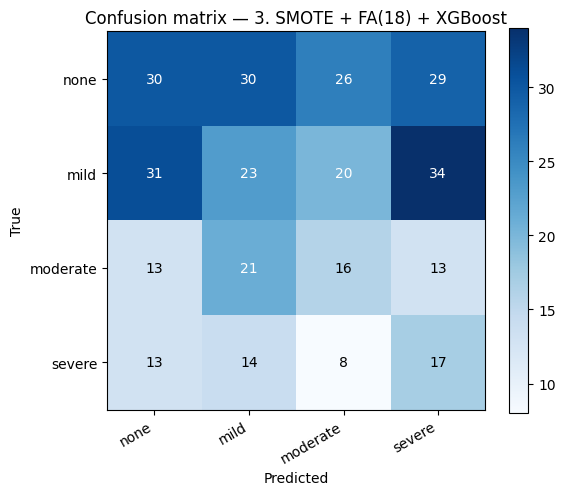


  MULTICLASS COMPARISON SUMMARY (sorted by ROC_AUC_OVR)


,model,roc_auc_ovr,accuracy,f1_macro
0,3. SMOTE + FA(18) + XGBoost,0.5298,0.2544,0.2517
1,2. FA(18) + XGBoost,0.5177,0.3225,0.2469
2,1. Raw XGBoost (no FA),0.5057,0.3077,0.2449
3,5. Dummy (most_frequent),0.5000,0.3402,0.1269
4,4. BalancedRandomForest (no FA),0.4886,0.2604,0.2061


In [21]:

# ── multiclass summary + confusion matrix + mlflow ────────────────────────────
best_mc_idx   = int(pd.DataFrame(mc_results)[SORT_METRIC_MC].idxmax())
mc_results_df = pd.DataFrame(mc_results).sort_values(SORT_METRIC_MC, ascending=False).reset_index(drop=True)
mc_winner     = mc_results_df.iloc[0]

# confusion matrix for the best model
best_mc_model, best_mc_X = mc_models[best_mc_idx]
cm_mc = confusion_matrix(yte_mc, np.asarray(best_mc_model.predict(best_mc_X)))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_mc, cmap="Blues")
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(MC_NAMES, rotation=30, ha="right")
ax.set_yticklabels(MC_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion matrix — {mc_winner['model']}")
for i in range(4):
    for j in range(4):
        ax.text(j, i, cm_mc[i, j], ha="center", va="center",
                color="white" if cm_mc[i, j] > cm_mc.max() / 2 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout()
mlflow.end_run()  # end previous run if still active

with mlflow.start_run(run_name="multiclass_ahi_comparison"):
    mlflow.log_metric(f"best_{SORT_METRIC_MC}", float(mc_winner[SORT_METRIC_MC]))
    mlflow.log_metric("best_accuracy",    float(mc_winner["accuracy"]))
    mlflow.log_metric("best_f1_macro",    float(mc_winner["f1_macro"]))
    mlflow.log_param("best_model",        mc_winner["model"])
    mlflow.log_param("label_scheme",      "none<5 / mild5-14 / moderate15-29 / severe≥30")
    mlflow.log_text(mc_results_df.to_csv(index=False) or "", "multiclass_comparison.csv")
    mlflow.log_figure(fig, "multiclass_confusion_matrix.png")

plt.show()

print("\n" + "=" * 58)
print(f"  MULTICLASS COMPARISON SUMMARY (sorted by {SORT_METRIC_MC.upper()})")
print("=" * 58)
display(mc_results_df)


## Approach A — Binary at AHI≥15 (moderate+ apnea)

Clinically, moderate-to-severe OSA (AHI≥15) is the actionable threshold for treatment. The class balance is also better than AHI≥5. Testing whether this target gives cleaner signal.

In [22]:

# ── binary AHI≥15 dataset ─────────────────────────────────────────────────────
df_15 = df.copy()
X_15  = df_15.drop(columns=["ahi"])
y_15  = convert_ahi(df_15["ahi"], threshold=15)   # moderate-or-severe vs none/mild

_splits15 = train_test_split(X_15, y_15, test_size=0.2, random_state=42, stratify=y_15)
Xtr15, Xte15, ytr15, yte15 = _splits15[0], _splits15[1], _splits15[2], _splits15[3]

neg15, pos15 = (ytr15 == 0).sum(), (ytr15 == 1).sum()
spw15 = neg15 / pos15

print(f"AHI≥15  train  — 0 (none/mild): {neg15},  1 (mod+sev): {pos15}  "
      f"(prevalence={pos15/(neg15+pos15):.1%}, spw={spw15:.2f})")
print(f"AHI≥15  test   — 0: {(yte15==0).sum()},  1: {(yte15==1).sum()}")


AHI≥15  train  — 0 (none/mild): 888,  1 (mod+sev): 461  (prevalence=34.2%, spw=1.93)
AHI≥15  test   — 0: 222,  1: 116


In [23]:

import lightgbm as lgb

# ── model comparison at AHI≥15 ────────────────────────────────────────────────
res15 = []
store15 = []

# 1. Raw XGBoost
m = XGBClassifier(n_estimators=250, max_depth=4, random_state=42, eval_metric="logloss")
m.fit(Xtr15, ytr15)
store15.append((m, Xte15))
res15.append(evaluate("1. Raw XGBoost", yte15, m.predict(Xte15), m.predict_proba(Xte15)))

# 2. XGBoost + scale_pos_weight
m = XGBClassifier(n_estimators=250, max_depth=4, random_state=42,
                  scale_pos_weight=spw15, eval_metric="logloss")
m.fit(Xtr15, ytr15)
store15.append((m, Xte15))
res15.append(evaluate("2. XGBoost + scale_pos_weight", yte15, m.predict(Xte15), m.predict_proba(Xte15)))

# 3. FA(18) + XGBoost + scale_pos_weight
m = Pipeline([
    ("fa",  Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)),
    ("clf", XGBClassifier(n_estimators=250, max_depth=4, random_state=42,
                          scale_pos_weight=spw15, eval_metric="logloss")),
])
m.fit(Xtr15, ytr15)
store15.append((m, Xte15))
res15.append(evaluate("3. FA(18) + XGBoost + scale_pos_weight", yte15, m.predict(Xte15), m.predict_proba(Xte15)))

# 4. SMOTE + FA(18) + XGBoost
_fa_15 = Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)
Xtr15_fa = _fa_15.fit_transform(Xtr15)
Xte15_fa = _fa_15.transform(Xte15)
Xr15, yr15 = SMOTE(random_state=42).fit_resample(Xtr15_fa, ytr15)
m = XGBClassifier(n_estimators=250, max_depth=4, random_state=42, eval_metric="logloss")
m.fit(Xr15, yr15)
store15.append((m, Xte15_fa))
res15.append(evaluate("4. SMOTE + FA(18) + XGBoost", yte15, m.predict(Xte15_fa), m.predict_proba(Xte15_fa)))

# 5. BalancedRandomForest
m = BalancedRandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
m.fit(Xtr15, ytr15)
store15.append((m, Xte15))
res15.append(evaluate("5. BalancedRandomForest", yte15, m.predict(Xte15), m.predict_proba(Xte15)))

# 6. LightGBM — is_unbalance handles class skew natively
m = lgb.LGBMClassifier(
    n_estimators=300, max_depth=4, random_state=42,
    is_unbalance=True, verbose=-1,
)
m.fit(Xtr15, ytr15)
store15.append((m, Xte15))
res15.append(evaluate("6. LightGBM (is_unbalance)", yte15, m.predict(Xte15), m.predict_proba(Xte15)))

# ── optimal threshold on best model ──────────────────────────────────────────
best15_list_idx = int(pd.DataFrame(res15)[SORT_METRIC].idxmax())
best15_obj, best15_X = store15[best15_list_idx]
best15_name = res15[best15_list_idx]["model"]
best15_proba = best15_obj.predict_proba(best15_X)[:, 1]
fpr15, tpr15, thresholds15 = roc_curve(yte15, best15_proba)
best15_thresh = float(thresholds15[(tpr15 - fpr15).argmax()])
res15.append(evaluate(
    f"7. {best15_name.split('. ', 1)[1]} + thresh={best15_thresh:.2f}",
    yte15, (best15_proba >= best15_thresh).astype(int),
    best15_obj.predict_proba(best15_X),
    threshold=best15_thresh,
))

# ── log to mlflow ─────────────────────────────────────────────────────────────
res15_df = pd.DataFrame(res15).sort_values(SORT_METRIC, ascending=False).reset_index(drop=True)
winner15 = res15_df.iloc[0]

mlflow.end_run()
with mlflow.start_run(run_name="binary_ahi15_comparison"):
    mlflow.log_param("ahi_threshold", 15)
    mlflow.log_text(res15_df.to_csv(index=False) or "", "binary_ahi15_comparison.csv")
    mlflow.log_metric(f"best_{SORT_METRIC}", float(winner15[SORT_METRIC]))
    mlflow.log_metric("best_accuracy", float(winner15["accuracy"]))
    mlflow.log_metric("best_f1_macro", float(winner15["f1_macro"]))
    mlflow.log_param("best_model", winner15["model"])

print("\n" + "=" * 58)
print(f"  AHI≥15 BINARY COMPARISON (sorted by {SORT_METRIC.upper()})")
print("=" * 58)
display(res15_df)



──────────────────────────────────────────────────────────
  1. Raw XGBoost
──────────────────────────────────────────────────────────
  ROC-AUC : 0.5451  |  Accuracy : 0.6006  |  F1-macro : 0.5010  (thresh=0.50)
              precision    recall  f1-score   support

    no_apnea       0.66      0.80      0.72       222
       apnea       0.37      0.22      0.28       116

    accuracy                           0.60       338
   macro avg       0.51      0.51      0.50       338
weighted avg       0.56      0.60      0.57       338


──────────────────────────────────────────────────────────
  2. XGBoost + scale_pos_weight
──────────────────────────────────────────────────────────
  ROC-AUC : 0.5410  |  Accuracy : 0.6036  |  F1-macro : 0.5296  (thresh=0.50)
              precision    recall  f1-score   support

    no_apnea       0.68      0.76      0.72       222
       apnea       0.40      0.30      0.34       116

    accuracy                           0.60       338
   macro avg

,model,roc_auc,accuracy,f1_macro,threshold
0,5. BalancedRandomForest,0.5690,0.6183,0.5293,0.50
1,7. BalancedRandomForest + thresh=0.47,0.5690,0.6065,0.5813,0.47
2,1. Raw XGBoost,0.5451,0.6006,0.5010,0.50
3,2. XGBoost + scale_pos_weight,0.5410,0.6036,0.5296,0.50
4,6. LightGBM (is_unbalance),0.5293,0.5769,0.5123,0.50
5,4. SMOTE + FA(18) + XGBoost,0.4964,0.5296,0.5009,0.50
6,3. FA(18) + XGBoost + scale_pos_weight,0.4724,0.4586,0.4364,0.50


## Approach B — Ordinal Classification (mord) + LightGBM

The 4 AHI severity classes have a natural order (none < mild < moderate < severe).

**`mord.LogisticAT`** (All-Thresholds variant of proportional-odds logistic regression) is a proper ordinal classifier — it learns a single linear scoring function and K-1 shared thresholds, enforcing the monotone ordering directly in the loss.

**LightGBM** (`is_unbalance=True`) is added to both the binary and ordinal comparisons as a fast, often stronger gradient-boosting baseline.


──────────────────────────────────────────────────────────
  mord LogisticAT (raw)
──────────────────────────────────────────────────────────
  ROC-AUC(OvR/macro): 0.4988  |  Acc: 0.2988  |  F1-macro: 0.1954
              precision    recall  f1-score   support

        none       0.30      0.14      0.19       115
        mild       0.32      0.71      0.44       108
    moderate       0.18      0.13      0.15        63
      severe       0.00      0.00      0.00        52

    accuracy                           0.30       338
   macro avg       0.20      0.24      0.20       338
weighted avg       0.24      0.30      0.23       338


──────────────────────────────────────────────────────────
  mord LogisticAT (FA-18)
──────────────────────────────────────────────────────────
  ROC-AUC(OvR/macro): 0.4922  |  Acc: 0.3195  |  F1-macro: 0.1211
              precision    recall  f1-score   support

        none       0.00      0.00      0.00       115
        mild       0.32      1.00   

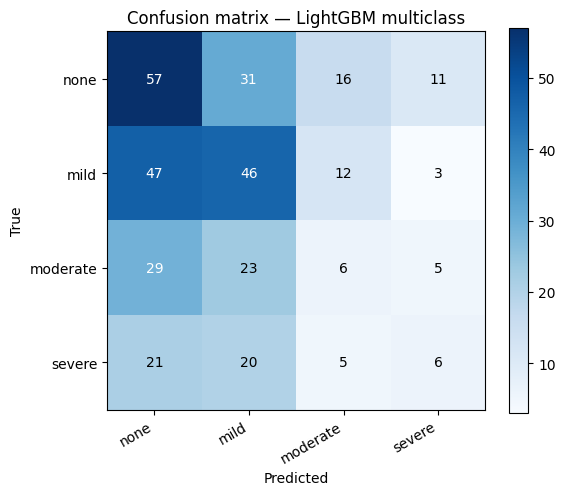


  ORDINAL (mord/LightGBM) vs STANDARD MULTICLASS
  sorted by ROC-AUC OvR


,model,roc_auc_ovr,accuracy,f1_macro
0,3. SMOTE + FA(18) + XGBoost,0.5298,0.2544,0.2517
1,LightGBM multiclass,0.5183,0.3402,0.2752
2,2. FA(18) + XGBoost,0.5177,0.3225,0.2469
3,1. Raw XGBoost (no FA),0.5057,0.3077,0.2449
4,5. Dummy (most_frequent),0.5000,0.3402,0.1269
5,mord LogisticAT (raw),0.4988,0.2988,0.1954
6,mord LogisticAT (FA-18),0.4922,0.3195,0.1211
7,4. BalancedRandomForest (no FA),0.4886,0.2604,0.2061


In [24]:

# ── ordinal dataset (same 4-class split used by multiclass section) ───────────
# Xtr_mc / Xte_mc / ytr_mc / yte_mc already in scope

# mord expects integer class labels starting at 0 — already the case (0,1,2,3)

# ── 1. mord LogisticAT on raw features (needs scaling) ───────────────────────
scaler_raw = StandardScaler()
Xtr_sc = scaler_raw.fit_transform(Xtr_mc)
Xte_sc = scaler_raw.transform(Xte_mc)

ord_mord_raw = mord.LogisticAT(alpha=1.0)
ord_mord_raw.fit(Xtr_sc, ytr_mc)
ord_mord_raw_proba = ord_mord_raw.predict_proba(Xte_sc)
ord_mord_raw_preds = ord_mord_raw.predict(Xte_sc)

# ── 2. mord LogisticAT on FA(18) features ────────────────────────────────────
_fa_ord = Factor_Analyzer_Transformer(rotation="varimax", n_factors=18)
Xtr_ord_fa = _fa_ord.fit_transform(Xtr_mc)
Xte_ord_fa = _fa_ord.transform(Xte_mc)

scaler_fa = StandardScaler()
Xtr_ord_fa_sc = scaler_fa.fit_transform(Xtr_ord_fa)
Xte_ord_fa_sc = scaler_fa.transform(Xte_ord_fa)

ord_mord_fa = mord.LogisticAT(alpha=1.0)
ord_mord_fa.fit(Xtr_ord_fa_sc, ytr_mc)
ord_mord_fa_proba = ord_mord_fa.predict_proba(Xte_ord_fa_sc)
ord_mord_fa_preds = ord_mord_fa.predict(Xte_ord_fa_sc)

# ── 3. LightGBM multiclass (is_unbalance handles class skew) ─────────────────
lgb_mc = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=4,
    random_state=42,
    is_unbalance=True,
    objective="multiclass",
    num_class=4,
    verbose=-1,
)
lgb_mc.fit(Xtr_mc, ytr_mc)
lgb_mc_proba = lgb_mc.predict_proba(Xte_mc)
lgb_mc_preds = lgb_mc.predict(Xte_mc)

# ── evaluate ──────────────────────────────────────────────────────────────────
ord_results = [
    evaluate_mc("mord LogisticAT (raw)",    yte_mc, ord_mord_raw_preds, ord_mord_raw_proba),
    evaluate_mc("mord LogisticAT (FA-18)",  yte_mc, ord_mord_fa_preds,  ord_mord_fa_proba),
    evaluate_mc("LightGBM multiclass",       yte_mc, lgb_mc_preds,        lgb_mc_proba),
]

# ── compare against standard multiclass results ───────────────────────────────
ord_df = pd.DataFrame(ord_results)
comparison_df = pd.concat(
    [mc_results_df[["model", "roc_auc_ovr", "accuracy", "f1_macro"]], ord_df],
    ignore_index=True,
).sort_values("roc_auc_ovr", ascending=False).reset_index(drop=True)

# ── confusion matrix for best ordinal/lgbm result ────────────────────────────
best_ord_row = ord_df.sort_values("roc_auc_ovr", ascending=False).iloc[0]
best_ord_name = best_ord_row["model"]

if best_ord_name == "mord LogisticAT (raw)":
    _best_preds = np.asarray(ord_mord_raw_preds)
elif best_ord_name == "mord LogisticAT (FA-18)":
    _best_preds = np.asarray(ord_mord_fa_preds)
else:
    _best_preds = np.asarray(lgb_mc_preds)

cm_ord = confusion_matrix(yte_mc, _best_preds)
fig_ord, ax_ord = plt.subplots(figsize=(6, 5))
im_ord = ax_ord.imshow(cm_ord, cmap="Blues")
ax_ord.set_xticks(range(4)); ax_ord.set_yticks(range(4))
ax_ord.set_xticklabels(MC_NAMES, rotation=30, ha="right")
ax_ord.set_yticklabels(MC_NAMES)
ax_ord.set_xlabel("Predicted"); ax_ord.set_ylabel("True")
ax_ord.set_title(f"Confusion matrix — {best_ord_name}")
for i in range(4):
    for j in range(4):
        ax_ord.text(j, i, cm_ord[i, j], ha="center", va="center",
                    color="white" if cm_ord[i, j] > cm_ord.max() / 2 else "black")
plt.colorbar(im_ord, ax=ax_ord)
plt.tight_layout()

# ── mlflow ──────────────────────────────────────────────────────────────────
mlflow.end_run()
with mlflow.start_run(run_name="ordinal_mord_lgbm_comparison"):
    for row in ord_results:
        prefix = _safe_metric_key(row["model"])
        mlflow.log_metric(f"{prefix}_roc_auc_ovr", float(row["roc_auc_ovr"]))
        mlflow.log_metric(f"{prefix}_accuracy",    float(row["accuracy"]))
        mlflow.log_metric(f"{prefix}_f1_macro",    float(row["f1_macro"]))
    mlflow.log_text(comparison_df.to_csv(index=False) or "", "ordinal_mord_lgbm_vs_standard_mc.csv")
    mlflow.log_figure(fig_ord, "ordinal_best_confusion_matrix.png")

plt.show()

print("\n" + "=" * 58)
print("  ORDINAL (mord/LightGBM) vs STANDARD MULTICLASS")
print("  sorted by ROC-AUC OvR")
print("=" * 58)
display(comparison_df)


## Overall Summary — All Approaches

Unified comparison across every section of the notebook.
`roc_auc` is the standard binary ROC-AUC for binary tasks and ROC-AUC OvR (macro) for multiclass/ordinal tasks.

In [25]:
# 1. Binary AHI≥5 — original model comparison
s1 = _tag(results_df, "Binary AHI≥5")

# 2. AHI threshold sweep — one FA(18)+XGB row per threshold
thresh_best = thresh_df[["label", "roc_auc", "accuracy", "f1_macro"]].copy()
thresh_best.insert(0, "approach", "AHI threshold sweep")
thresh_best = thresh_best.rename(columns={"label": "model"})

# 3. Binary AHI≥15
s3 = _tag(res15_df, "Binary AHI≥15")

# 4. Multiclass 4-class
s4 = _tag(mc_results_df, "Multiclass 4-class", auc_col="roc_auc_ovr")

# 5. Ordinal / mord / LightGBM (the three new models only — mc already in s4)
s5 = _tag(ord_df, "Ordinal / mord / LightGBM", auc_col="roc_auc_ovr")

overall_df = (
    pd.concat([s1, thresh_best, s3, s4, s5], ignore_index=True)
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)

# ── best result per approach ─────────────────────────────────────────────────
best_per_approach = (
    overall_df.groupby("approach", sort=False)
    .apply(lambda g: g.loc[g["roc_auc"].idxmax()])
    .reset_index(drop=True)[["approach", "model", "roc_auc", "accuracy", "f1_macro"]]
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)

# ── log to mlflow ─────────────────────────────────────────────────────────────
mlflow.end_run()
with mlflow.start_run(run_name="overall_summary_comparison"):
    mlflow.log_text(overall_df.to_csv(index=False) or "", "overall_summary.csv")
    mlflow.log_text(
        best_per_approach.to_csv(index=False) or "", "best_per_approach.csv"
    )
    for _, row in best_per_approach.iterrows():
        key = re.sub(r"[^a-zA-Z0-9_]", "_", row["approach"])
        mlflow.log_metric(f"best_roc_auc_{key}", float(round(float(row["roc_auc"]), 4)))

# ── display ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 64)
print("  BEST MODEL PER APPROACH")
print("=" * 64)
display(
    best_per_approach.style.format(
        {"roc_auc": "{:.4f}", "accuracy": "{:.4f}", "f1_macro": "{:.4f}"}
    ).background_gradient(subset=["roc_auc"], cmap="RdYlGn", vmin=0.45, vmax=0.65)
)

print("\n" + "=" * 64)
print("  ALL MODELS — RANKED BY ROC-AUC")
print("=" * 64)
display(
    overall_df.style.format(
        {"roc_auc": "{:.4f}", "accuracy": "{:.4f}", "f1_macro": "{:.4f}"}
    )
    .background_gradient(subset=["roc_auc"], cmap="RdYlGn", vmin=0.45, vmax=0.65)
    .set_caption("Overall comparison — all approaches (sorted by ROC-AUC)")
)


  BEST MODEL PER APPROACH


,approach,model,roc_auc,accuracy,f1_macro
0,Binary AHI≥15,7. BalancedRandomForest + thresh=0.47,0.5690,0.6065,0.5813
1,AHI threshold sweep,AHI≥5,0.5400,0.5385,0.5190
2,Binary AHI≥5,7. FA(18) + XGBoost + scale_pos_weight + thresh=0.52,0.5400,0.5503,0.5357
3,Multiclass 4-class,3. SMOTE + FA(18) + XGBoost,0.5298,0.2544,0.2517
4,Ordinal / mord / LightGBM,LightGBM multiclass,0.5183,0.3402,0.2752



  ALL MODELS — RANKED BY ROC-AUC


,approach,model,roc_auc,accuracy,f1_macro
0,Binary AHI≥15,7. BalancedRandomForest + thresh=0.47,0.5690,0.6065,0.5813
1,Binary AHI≥15,5. BalancedRandomForest,0.5690,0.6183,0.5293
2,Binary AHI≥15,1. Raw XGBoost,0.5451,0.6006,0.5010
3,Binary AHI≥15,2. XGBoost + scale_pos_weight,0.5410,0.6036,0.5296
4,AHI threshold sweep,AHI≥5,0.5400,0.5385,0.5190
5,Binary AHI≥5,7. FA(18) + XGBoost + scale_pos_weight + thresh=0.52,0.5400,0.5503,0.5357
6,Binary AHI≥5,3. FA(18) + XGBoost + scale_pos_weight,0.5400,0.5385,0.5190
7,AHI threshold sweep,AHI≥30,0.5320,0.5799,0.4624
8,Multiclass 4-class,3. SMOTE + FA(18) + XGBoost,0.5298,0.2544,0.2517
9,Binary AHI≥15,6. LightGBM (is_unbalance),0.5293,0.5769,0.5123


steps to take maybe
1. Feature selection before FA — use only the ~6 top SHAP factors' original variables as input to FA, rather than all features. Less noise going in
2. smoteenn or smotetomek?
3. lightgbm maybe 
4. stacking ensembles 
5. cross-validate shap values